# v1.1

## BiRNN + Skip (No Attention)

This notebook is the **skip-only continuation** of `daily_birnn_attention.ipynb`.
We keep the same training/evaluation workflow so result differences are driven by architecture, not pipeline changes.

This is intended for fair comparison across:

- `daily_birnn_attention.ipynb` (BiRNN + Attention)
- `daily_birnn_skip_only.ipynb` (this file: BiRNN + Skip, no Attention)
- `daily_birnn_skip_attention.ipynb` (BiRNN + Skip + Attention)

### Changelog (v1.0 -> v1.1)

- Rebased this notebook on the updated `daily_birnn_attention.ipynb` workflow for apples-to-apples comparison.
- Kept the architectural delta focused: skip/residual stack is retained, attention is removed.
- Updated `fit()` to train on full `X_train` (matching attention notebook behavior) instead of only the last CV fold.
- Added tail diagnostic outputs (last 20% of `X_train`) so diagnostics remain consistent with the attention notebook.
- Expanded Default/Optuna plots to show tail diagnostic + train + test predictions.
- Tightened Optuna learning-rate search to `1e-4`..`1e-3` and reduced trials to `25` to match comparison settings.
- Fixed CV progress tracking with `tqdm(..., total=5)`.
- Corrected comparison-table labels to skip-only naming.

### What changed from skip-attention version

- Removed attention layer; retained skip/residual BiRNN stack.
- Kept data pipeline, metrics, and evaluation flow aligned with the attention notebook.
- Preserved notebook structure and naming to keep side-by-side review straightforward.


In [1]:
!pip install optuna --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 9.4 MB/s eta 0:00:00


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import pickle

#provided abstract class
from abc import ABC, abstractmethod

# sklearn import for tiem series cross checking
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# tensorflow import for model building
from tensorflow.keras import layers, regularizers, Input, Model, optimizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import seaborn as sns
import tensorflow as tf

#hyperparameter tuning done in prev sem
import optuna

#progress bar
from tqdm.notebook import tqdm

#connect to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Set random seeds

In [3]:
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
tf.keras.utils.set_random_seed(42)

## Abstract Base Class

In [4]:
class BaseForecastModel(ABC):
    """
    Simple base class for forecasting models.
    """

    def __init__(self, task_type: str, **hyperparameters):
        self.task_type = task_type
        self.hyperparameters = hyperparameters

    @abstractmethod
    def fit(self, X_train, y_train):
        pass

    @abstractmethod
    def predict(self, X):
        pass

    @abstractmethod
    def evaluate(self, X_test, y_test):
        pass

    @abstractmethod
    def save(self, filepath: str):
        pass

    @abstractmethod
    def load(self, filepath: str):
        pass

## Data Loading & Preprocessing

### Historical wheat futures prices data (1999-2025) from Investing.com

In [5]:


df1 = pd.read_csv('/content/drive/MyDrive/Quants /Investing.com/US Wheat Futures Historical Data_2018.csv')
df1['Date'] = pd.to_datetime(df1['Date'])
df1 = df1.set_index('Date', drop=True)
df1.sort_index(inplace=True)
df1['Price'] = df1['Price'].str.replace(',', '').astype('float64')
#df.to_csv('US Wheat Futures Historical Data.csv')
df1_price = df1['Price']


df2 = pd.read_csv('/content/drive/MyDrive/Quants /Investing.com/US Wheat Futures Historical Data_2025.csv')
df2['Date'] = pd.to_datetime(df2['Date'])
df2 = df2.set_index('Date', drop=True)
df2.sort_index(inplace=True)
df2['Price'] = df2['Price'].str.replace(',', '').astype('float64')
#df.to_csv('US Wheat Futures Historical Data.csv')
df2_price = df2['Price']


df = pd.concat([df1, df2.iloc[1:]])

df.to_csv('US Wheat Futures Historical Data.csv')
print("Head of merged DataFrame:")
print(df.head())
print("\nTail of merged DataFrame:")
print(df.tail())


df_price = df['Price']
df_price



Head of merged DataFrame:
             Price    Open    High     Low     Vol. Change %
Date                                                        
1999-08-01  264.75  264.00  286.75  259.00  160.06K    0.38%
1999-08-02  282.75  264.00  283.75  264.00   17.64K    6.80%
1999-08-03  272.00  282.00  286.75  271.00   14.02K   -3.80%
1999-08-04  276.50  271.25  276.75  269.00    4.98K    1.65%
1999-08-05  278.50  276.50  279.00  271.50    9.30K    0.72%

Tail of merged DataFrame:
             Price    Open    High     Low    Vol. Change %
Date                                                       
2025-12-08  534.75  535.25  540.00  532.50  49.77K   -0.19%
2025-12-09  534.50  535.50  537.75  531.25  54.30K   -0.05%
2025-12-10  529.50  534.00  535.00  525.25  68.63K   -0.94%
2025-12-11  533.50  529.75  534.75  529.25  62.42K    0.76%
2025-12-12  530.50  534.50  536.00  529.10  24.57K   -0.56%


,Price
Date,
1999-08-01,264.75
1999-08-02,282.75
1999-08-03,272.00
1999-08-04,276.50
1999-08-05,278.50
...,...
2025-12-08,534.75
2025-12-09,534.50
2025-12-10,529.50


### Macroeconomics data (1999-08 ~ 2024-12) from FRED

In [6]:
df_features = pd.read_csv('/content/drive/MyDrive/Quants /FredMD_Dataset/FRED.csv')
df_features = df_features.dropna(how='all', axis=1)
features_missing = []

for col in df_features.columns:
    if col == "Month":
        continue
    s = df_features[col].isna() | (df_features[col] == "")
    if not s.any():
        continue
    features_missing.append(col)

df_features['Month'] = pd.to_datetime(df_features['Month'])
df_features = df_features.set_index('Month').sort_index()
df_selected = df_features.drop(columns=features_missing)
features = [
    "RPI", "W875RX1", "CMRMTSPLx",
    "IPFPNSS", "USWTRADE",
    "USTRADE", "BUSLOANS", "CONSPI", "S&P 500",
    "S&P PE ratio", "FEDFUNDS", "TB3MS", "TB6MS", "GS1", "GS5",
    "GS10", "AAA", "BAA", "TB3SMFFM", "TB6SMFFM", "T1YFFM",
    "T5YFFM", "T10YFFM", "AAAFFM", "BAAFFM",
    "EXSZUSx", "EXJPUSx", "EXUSUKx", "EXCAUSx",
    "PPICMM", "UMCSENTx"
]

df_features = df_features[features]
df_features

,RPI,W875RX1,CMRMTSPLx,IPFPNSS,USWTRADE,USTRADE,BUSLOANS,CONSPI,S&P 500,S&P PE ratio,...,T5YFFM,T10YFFM,AAAFFM,BAAFFM,EXSZUSx,EXJPUSx,EXUSUKx,EXCAUSx,PPICMM,UMCSENTx
Month,,,,,,,,,,,,,,,,,,,,,
1999-08-01,3836.968313,3321.054004,434465.878601,76.546257,4919.936345,14699.952772,485.720063,0.131076,240.916879,15.946036,...,0.605051,0.764969,1.457803,2.445585,2.688368,245.582877,2.079388,1.164031,84.141068,86.870270
1999-09-01,3842.561807,3321.054004,434465.878601,76.647955,4924.282787,14716.772541,488.191875,0.131016,243.143463,15.946036,...,0.605389,0.765184,1.459590,2.446885,2.685952,245.311656,2.078418,1.164706,84.190164,86.923054
1999-10-01,3848.215369,3325.640164,435231.819302,76.748350,4928.615542,14733.366053,489.693146,0.130962,245.341881,15.946036,...,0.605337,0.765051,1.461043,2.447975,2.683581,245.028555,2.077490,1.165345,84.245808,86.983582
1999-11-01,7120.796970,5617.389362,435231.819302,76.878239,4932.944898,14749.936735,491.519876,0.129403,247.494265,16.060393,...,0.605796,0.765347,1.462857,2.449469,2.681144,244.744752,2.076632,1.165982,84.305102,87.031845
1999-12-01,4191.127291,4126.544304,435231.819302,76.987908,4937.331976,14766.598778,493.105573,0.129341,249.823198,16.060393,...,0.605682,0.765031,1.463829,2.450041,2.678849,244.459423,2.075703,1.166596,84.370265,87.091691
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-01,9492.169116,8090.965184,820836.295036,71.747139,4775.909784,11914.240915,842.746761,0.135582,925.983875,19.389145,...,0.693482,1.003685,2.001372,3.001321,2.088519,193.962642,1.870707,1.197099,126.494198,85.244708
2024-09-01,9519.405260,8109.921193,822489.552603,71.782490,4777.690102,11918.954061,845.149648,0.135488,931.760812,19.422432,...,0.690546,1.000558,1.998249,2.997855,2.086957,193.902111,1.869976,1.197313,126.678704,85.217350
2024-10-01,9532.882349,8120.457541,821633.252409,71.819452,4779.453739,11923.708238,847.602589,0.135506,937.704411,19.422432,...,0.687605,0.997503,1.995146,2.994423,2.085386,193.837538,1.869281,1.197512,126.864238,85.193543


### Shift the dates of macroeconomics data by 1 month into the future, since each month's macroeconomics data is usually released in the next month and remains unknown in the current month. Then use forward-fill to transform monthly data into daily series


In [7]:
df_features = df_features.shift(periods=1, freq='infer').dropna()

#take the earliest date of the month and make it the start date.
start = df_features.index.min().replace(day=1)
#take the last date of the month and make it the end date of the month.
end = (df_features.index.max() + pd.offsets.MonthEnd(0))
#create a date range from the start to end date.
all_days = pd.date_range(start, end, freq='D')
#reindex the dataframe with the date range and  forward fill the missing values.
df_features = df_features.reindex(all_days).ffill()
df_features

,RPI,W875RX1,CMRMTSPLx,IPFPNSS,USWTRADE,USTRADE,BUSLOANS,CONSPI,S&P 500,S&P PE ratio,...,T5YFFM,T10YFFM,AAAFFM,BAAFFM,EXSZUSx,EXJPUSx,EXUSUKx,EXCAUSx,PPICMM,UMCSENTx
1999-09-01,3836.968313,3321.054004,434465.878601,76.546257,4919.936345,14699.952772,485.720063,0.131076,240.916879,15.946036,...,0.605051,0.764969,1.457803,2.445585,2.688368,245.582877,2.079388,1.164031,84.141068,86.870270
1999-09-02,3836.968313,3321.054004,434465.878601,76.546257,4919.936345,14699.952772,485.720063,0.131076,240.916879,15.946036,...,0.605051,0.764969,1.457803,2.445585,2.688368,245.582877,2.079388,1.164031,84.141068,86.870270
1999-09-03,3836.968313,3321.054004,434465.878601,76.546257,4919.936345,14699.952772,485.720063,0.131076,240.916879,15.946036,...,0.605051,0.764969,1.457803,2.445585,2.688368,245.582877,2.079388,1.164031,84.141068,86.870270
1999-09-04,3836.968313,3321.054004,434465.878601,76.546257,4919.936345,14699.952772,485.720063,0.131076,240.916879,15.946036,...,0.605051,0.764969,1.457803,2.445585,2.688368,245.582877,2.079388,1.164031,84.141068,86.870270
1999-09-05,3836.968313,3321.054004,434465.878601,76.546257,4919.936345,14699.952772,485.720063,0.131076,240.916879,15.946036,...,0.605051,0.764969,1.457803,2.445585,2.688368,245.582877,2.079388,1.164031,84.141068,86.870270
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-27,9559.097642,8140.815297,823452.726454,71.888719,4783.035777,11933.070670,852.486774,0.135546,950.152996,19.458187,...,0.684172,0.993692,1.990872,2.989292,2.082316,193.731252,1.867814,1.197990,127.267574,85.149451
2025-01-28,9559.097642,8140.815297,823452.726454,71.888719,4783.035777,11933.070670,852.486774,0.135546,950.152996,19.458187,...,0.684172,0.993692,1.990872,2.989292,2.082316,193.731252,1.867814,1.197990,127.267574,85.149451
2025-01-29,9559.097642,8140.815297,823452.726454,71.888719,4783.035777,11933.070670,852.486774,0.135546,950.152996,19.458187,...,0.684172,0.993692,1.990872,2.989292,2.082316,193.731252,1.867814,1.197990,127.267574,85.149451
2025-01-30,9559.097642,8140.815297,823452.726454,71.888719,4783.035777,11933.070670,852.486774,0.135546,950.152996,19.458187,...,0.684172,0.993692,1.990872,2.989292,2.082316,193.731252,1.867814,1.197990,127.267574,85.149451


### Inner join wheat futures + macro data, filter post-2008.
Only use data starting in 2008 for training and testing, as financial markets generally behave differently before and after the 2008 financial crisis, leading to a structural break (this is a common practice in financial forecasting). Stale data may hurt model performances

In [8]:
df_all = df_features.join(df_price, how='inner')
df_all = df_all['2008-01-01':]
df_all

,RPI,W875RX1,CMRMTSPLx,IPFPNSS,USWTRADE,USTRADE,BUSLOANS,CONSPI,S&P 500,S&P PE ratio,...,T10YFFM,AAAFFM,BAAFFM,EXSZUSx,EXJPUSx,EXUSUKx,EXCAUSx,PPICMM,UMCSENTx,Price
2008-01-01,5206.744804,4559.022147,515616.765189,63.553108,4477.462862,10783.078876,460.495911,0.131964,407.244378,17.712774,...,0.850221,1.663748,2.639642,2.470920,223.330371,2.013369,1.195918,96.012947,88.098614,929.50
2008-01-02,5206.744804,4559.022147,515616.765189,63.553108,4477.462862,10783.078876,460.495911,0.131964,407.244378,17.712774,...,0.850221,1.663748,2.639642,2.470920,223.330371,2.013369,1.195918,96.012947,88.098614,915.00
2008-01-03,5206.744804,4559.022147,515616.765189,63.553108,4477.462862,10783.078876,460.495911,0.131964,407.244378,17.712774,...,0.850221,1.663748,2.639642,2.470920,223.330371,2.013369,1.195918,96.012947,88.098614,945.00
2008-01-04,5206.744804,4559.022147,515616.765189,63.553108,4477.462862,10783.078876,460.495911,0.131964,407.244378,17.712774,...,0.850221,1.663748,2.639642,2.470920,223.330371,2.013369,1.195918,96.012947,88.098614,931.50
2008-01-07,5206.744804,4559.022147,515616.765189,63.553108,4477.462862,10783.078876,460.495911,0.131964,407.244378,17.712774,...,0.850221,1.663748,2.639642,2.470920,223.330371,2.013369,1.195918,96.012947,88.098614,903.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-27,9559.097642,8140.815297,823452.726454,71.888719,4783.035777,11933.070670,852.486774,0.135546,950.152996,19.458187,...,0.993692,1.990872,2.989292,2.082316,193.731252,1.867814,1.197990,127.267574,85.149451,535.50
2025-01-28,9559.097642,8140.815297,823452.726454,71.888719,4783.035777,11933.070670,852.486774,0.135546,950.152996,19.458187,...,0.993692,1.990872,2.989292,2.082316,193.731252,1.867814,1.197990,127.267574,85.149451,545.25
2025-01-29,9559.097642,8140.815297,823452.726454,71.888719,4783.035777,11933.070670,852.486774,0.135546,950.152996,19.458187,...,0.993692,1.990872,2.989292,2.082316,193.731252,1.867814,1.197990,127.267574,85.149451,562.50
2025-01-30,9559.097642,8140.815297,823452.726454,71.888719,4783.035777,11933.070670,852.486774,0.135546,950.152996,19.458187,...,0.993692,1.990872,2.989292,2.082316,193.731252,1.867814,1.197990,127.267574,85.149451,566.50


### There are 32 features in total (including wheat futures price itself), and the lookback period is 30 days before the target date. So each X sample has a rectangular shape (30 * 32). We are doing one-step-ahead forecast, so each y label is just target day's wheat futures price

In [9]:
lookback = 30

data = df_all.values
X, y = [], []
for i in range(len(data) - lookback):
    seq_x = data[i : i + lookback, :]
    target = data[i + lookback, -1]
    X.append(seq_x)
    y.append(target)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4458, 30, 32)
y shape: (4458,)


### Price plot

<Axes: >

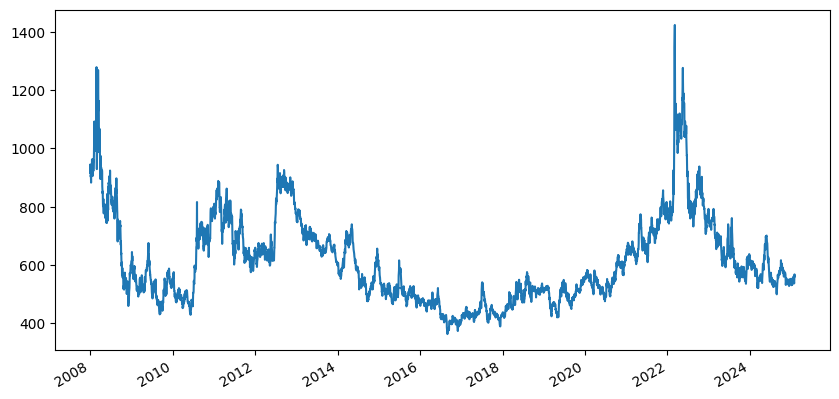

In [10]:
df_all['Price'].plot(figsize=(10, 5))

### 80/20 train-test split (no shuffling)

In [11]:
test_size = int(X.shape[0] * 0.2)

X_train = X[:-test_size]
y_train = y[:-test_size]

X_test = X[-test_size:]
y_test = y[-test_size:]

print("Training set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)

Training set: (3567, 30, 32) (3567,)
Test set: (891, 30, 32) (891,)


### Chronological train-test split visualization

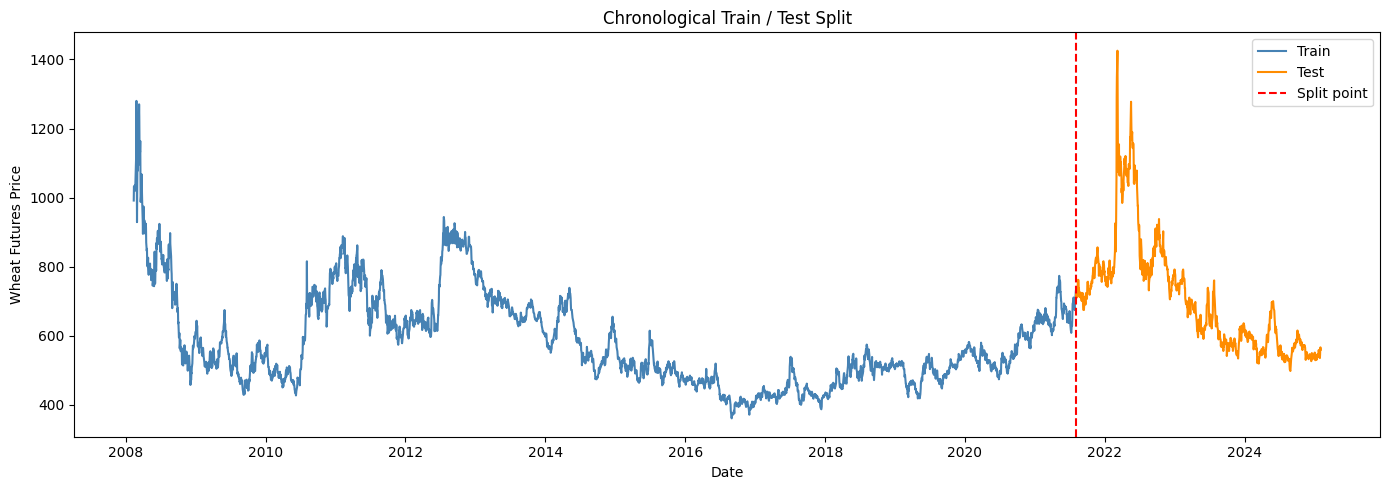

In [12]:
target_dates = df_all.index[lookback:]
train_dates = target_dates[:len(y_train)]
test_dates  = target_dates[len(y_train):]

plt.figure(figsize=(14, 5))
plt.plot(train_dates, y_train, label='Train', color='steelblue')
plt.plot(test_dates, y_test, label='Test', color='darkorange')
plt.axvline(x=train_dates[-1], color='red', linestyle='--', linewidth=1.5, label='Split point')
plt.title('Chronological Train / Test Split')
plt.xlabel('Date')
plt.ylabel('Wheat Futures Price')
plt.legend()
plt.tight_layout()
plt.show()

## BiRNN with Skip Connections (No Attention) (implements BaseForecastModel)

Architecture:
- **Input projection**: Dense layer maps raw features to `2 * hidden_size` so residual additions are dimension-compatible with the BiRNN output
- **Stacked BiRNN layers with skip connections**: each layer is a `Bidirectional(SimpleRNN)` whose output is added back to its input (residual), followed by `LayerNormalization`:

$$
\tilde{H}^{(l)} = \text{LayerNorm}\!\left(H^{(l)} + H^{(l-1)}\right)
$$

- **Global average pooling**: collapses sequence features into a single vector
- **Dense head**: produces the scalar price prediction

```
Input (B, T, F)
  -> Dense(F -> 2H)                        [input projection]
  -> BiRNN layer 1 + Skip + LayerNorm
  -> BiRNN layer 2 + Skip + LayerNorm
  -> ...
  -> GlobalAveragePooling1D
  -> Dropout
  -> Dense(1) -> scalar prediction
```

The `fit()` method trains the final model on full `X_train` and stores the scalers. `predict()` reuses those exact scalers — no separate scaler is ever created for the test set.

In [13]:
class BiRNNSkipOnlyModel(BaseForecastModel):
    """
    Bidirectional SimpleRNN with skip/residual connections (no attention)
    for one-step-ahead wheat futures price forecasting.
    """

    def __init__(
        self,
        task_type: str = 'regression',
        hidden_size: int = 64,
        num_layers: int = 2,
        weight_decay: float = 0.02,
        dropout: float = 0.2,
        early_stop_patience: int = 10,
        epochs: int = 100,
        batch_size: int = 64,
        learning_rate: float = 1e-3,
    ):
        super().__init__(
            task_type=task_type,
            hidden_size=hidden_size,
            num_layers=num_layers,
            weight_decay=weight_decay,
            dropout=dropout,
            early_stop_patience=early_stop_patience,
            epochs=epochs,
            batch_size=batch_size,
            learning_rate=learning_rate,
        )

        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.weight_decay = weight_decay
        self.dropout = dropout
        self.early_stop_patience = early_stop_patience
        self.epochs = epochs
        self.batch_size = batch_size
        self.learning_rate = learning_rate

        self.model = None
        self.x_scaler = None
        self.y_scaler = None
        self.lookback = None
        self.n_features = None

        # Stored after fit() for tail diagnostic plotting
        self._cv_val_actual = None
        self._cv_val_pred = None

    def _build_model(self, seq_length: int, feature_dim: int) -> Model:
        inputs = Input(shape=(seq_length, feature_dim))
        rnn_hidden = self.hidden_size * 2

        h = layers.Dense(
            rnn_hidden,
            kernel_regularizer=regularizers.l2(self.weight_decay),
        )(inputs)

        # Stacked BiRNN blocks with residual skip + LayerNorm
        for _ in range(self.num_layers):
            rnn_out = layers.Bidirectional(
                layers.SimpleRNN(
                    units=self.hidden_size,
                    dropout=self.dropout,
                    kernel_regularizer=regularizers.l2(self.weight_decay),
                    return_sequences=True,
                )
            )(h)
            h = layers.Add()([rnn_out, h])
            h = layers.LayerNormalization()(h)

        x = layers.GlobalAveragePooling1D()(h)
        x = layers.Dropout(self.dropout)(x)

        outputs = layers.Dense(
            units=1,
            activation='linear',
            kernel_regularizer=regularizers.l2(self.weight_decay),
        )(x)

        return Model(inputs=inputs, outputs=outputs)

    def _scale_X(self, X, fit: bool = False):
        n, lb, nf = X.shape
        X_flat = X.reshape(n, lb * nf)
        if fit:
            self.x_scaler = StandardScaler()
            X_flat = self.x_scaler.fit_transform(X_flat)
        else:
            X_flat = self.x_scaler.transform(X_flat)
        return X_flat.reshape(n, lb, nf)

    def fit(self, X_train, y_train):
        """
        Train final model on full X_train.

        Scalers are fitted on all training samples and reused by predict(),
        so there is no train/test scaler mismatch.

        For plotting compatibility, a tail-window diagnostic prediction
        (last 20% of X_train) is stored in _cv_val_actual / _cv_val_pred.
        """
        self.lookback = X_train.shape[1]
        self.n_features = X_train.shape[2]

        X_train_s = self._scale_X(X_train, fit=True)

        self.y_scaler = StandardScaler()
        y_train_s = self.y_scaler.fit_transform(y_train.reshape(-1, 1))

        self.model = self._build_model(self.lookback, self.n_features)
        self.model.compile(
            optimizer=Adam(learning_rate=self.learning_rate),
            loss='mean_squared_error',
        )

        callbacks = [
            EarlyStopping(
                monitor='loss',
                patience=self.early_stop_patience,
                restore_best_weights=True,
                verbose=0,
            ),
            ReduceLROnPlateau(
                monitor='loss',
                factor=0.5,
                patience=5,
                min_lr=1e-6,
                verbose=0,
            ),
        ]

        self.model.fit(
            X_train_s, y_train_s,
            epochs=self.epochs,
            batch_size=self.batch_size,
            shuffle=False,
            callbacks=callbacks,
            verbose=0,
        )

        y_train_pred = self.y_scaler.inverse_transform(
            self.model.predict(X_train_s, verbose=0).reshape(-1, 1)
        ).ravel()

        print("=== Train set performance (full X_train) ===")
        print(f"  RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred)):.6f}")
        print(f"  MAE : {mean_absolute_error(y_train, y_train_pred):.6f}")
        print(f"  R_SQUARED  : {r2_score(y_train, y_train_pred):.6f}")

        tail_n = max(1, int(len(X_train) * 0.2))
        X_tail = X_train[-tail_n:]
        y_tail = y_train[-tail_n:]
        X_tail_s = self._scale_X(X_tail, fit=False)
        y_tail_pred = self.y_scaler.inverse_transform(
            self.model.predict(X_tail_s, verbose=0).reshape(-1, 1)
        ).ravel()

        self._cv_val_actual = y_tail
        self._cv_val_pred = y_tail_pred

        print("=== Tail diagnostic performance (last 20% of X_train) ===")
        print(f"  RMSE: {np.sqrt(mean_squared_error(y_tail, y_tail_pred)):.6f}")
        print(f"  MAE : {mean_absolute_error(y_tail, y_tail_pred):.6f}")
        print(f"  R_SQUARED  : {r2_score(y_tail, y_tail_pred):.6f}")

    def predict(self, X):
        if self.model is None:
            raise ValueError("Model not trained - call fit() first.")
        X_s = self._scale_X(X, fit=False)
        y_pred_s = self.model.predict(X_s, verbose=0)
        return self.y_scaler.inverse_transform(y_pred_s.reshape(-1, 1)).ravel()

    def evaluate(self, X_test, y_test):
        preds = self.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        mae = mean_absolute_error(y_test, preds)
        r2 = r2_score(y_test, preds)
        return {'rmse': rmse, 'mae': mae, 'r2': r2}

    def save(self, filepath: str):
        self.model.save_weights(filepath + '.weights.h5')
        meta = {
            'hyperparameters': self.hyperparameters,
            'x_scaler': self.x_scaler,
            'y_scaler': self.y_scaler,
            'lookback': self.lookback,
            'n_features': self.n_features,
            'hidden_size': self.hidden_size,
            'num_layers': self.num_layers,
        }
        with open(filepath + '.meta.pkl', 'wb') as f:
            pickle.dump(meta, f)
        print(f"Model saved to {filepath}.*")

    def load(self, filepath: str):
        with open(filepath + '.meta.pkl', 'rb') as f:
            meta = pickle.load(f)
        self.x_scaler = meta['x_scaler']
        self.y_scaler = meta['y_scaler']
        self.lookback = meta['lookback']
        self.n_features = meta['n_features']
        self.hidden_size = meta['hidden_size']
        self.num_layers = meta['num_layers']
        self.model = self._build_model(self.lookback, self.n_features)
        self.model.load_weights(filepath + '.weights.h5')
        print(f"Model loaded from {filepath}.*")



### Cross-validation function

Runs 5-fold expanding-window CV and returns a metrics dict with average RMSE, MAE, R² and val_loss across folds.

In [14]:
def cv_birnn_skip_only(X_train, y_train, **kwargs):
    """Run 5-fold expanding-window CV; return dict of averaged metrics."""
    tscv = TimeSeriesSplit(n_splits=5)
    lookback, n_features = X_train.shape[1], X_train.shape[2]
    fold_metrics = {'val_loss': [], 'rmse': [], 'mae': [], 'r2': []}

    for fold, (train_idx, val_idx) in tqdm(enumerate(tscv.split(X_train)), total=5):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        ns_tr, ns_val = X_tr.shape[0], X_val.shape[0]
        X_tr_flat = X_tr.reshape((ns_tr, lookback * n_features))
        X_val_flat = X_val.reshape((ns_val, lookback * n_features))

        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_tr_flat).reshape((ns_tr, lookback, n_features))
        X_val_s = scaler.transform(X_val_flat).reshape((ns_val, lookback, n_features))

        y_scaler = StandardScaler()
        y_tr_s = y_scaler.fit_transform(y_tr.reshape(-1, 1))
        y_val_s = y_scaler.transform(y_val.reshape(-1, 1))

        tmp = BiRNNSkipOnlyModel(**kwargs)
        model = tmp._build_model(lookback, n_features)
        model.compile(
            optimizer=Adam(learning_rate=kwargs.get('learning_rate', 1e-3)),
            loss='mean_squared_error',
        )

        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=kwargs.get('early_stop_patience', 10),
            verbose=0,
            restore_best_weights=True,
        )
        #reduce learning rate when val_loss stops improving
        reduce_lr = ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0,
        )

        history = model.fit(
            X_tr_s, y_tr_s,
            validation_data=(X_val_s, y_val_s),
            epochs=kwargs.get('epochs', 100),
            batch_size=kwargs.get('batch_size', 64),
            shuffle=False,
            callbacks=[early_stop, reduce_lr],
            verbose=0,
        )
        fold_metrics['val_loss'].append(min(history.history['val_loss']))

        y_val_pred = y_scaler.inverse_transform(
            model.predict(X_val_s, verbose=0).reshape(-1, 1)
        ).ravel()
        fold_metrics['rmse'].append(np.sqrt(mean_squared_error(y_val, y_val_pred)))
        fold_metrics['mae'].append(mean_absolute_error(y_val, y_val_pred))
        fold_metrics['r2'].append(r2_score(y_val, y_val_pred))

    return {k: np.mean(v) for k, v in fold_metrics.items()}

## Default Hyperparameters — Training and Evaluation

Train the BiRNN + Skip (No Attention) model with **default** hyperparameters (hidden_size=64, num_layers=2, weight_decay=0.02, dropout=0.2, epochs=100, batch_size=64, lr=1e-3). Run full 5-fold CV for metrics, then train the final model on full X_train.

In [15]:
# 5-fold CV with default hyperparameters
default_cv_metrics = cv_birnn_skip_only(X_train, y_train)

print("=== Default CV Metrics (avg across 5 folds) ===")
for k, v in default_cv_metrics.items():
    print(f"  {k.upper():<10}: {v:.6f}")

  0%|          | 0/5 [00:00<?, ?it/s]

=== Default CV Metrics (avg across 5 folds) ===
  VAL_LOSS  : 0.520591
  RMSE      : 57.184699
  MAE       : 47.349063
  R2        : 0.336503


In [16]:
# Train final model with default hyperparameters
default_model = BiRNNSkipOnlyModel()
default_model.fit(X_train, y_train)

default_test_metrics = default_model.evaluate(X_test, y_test)
print('\n=== Default — Test set performance ===')
for k, v in default_test_metrics.items():
    print(f'  {k.upper():<10}: {v:.6f}')

=== Train set performance (full X_train) ===
  RMSE: 31.523183
  MAE : 22.225515
  R_SQUARED  : 0.945559
=== Tail diagnostic performance (last 20% of X_train) ===
  RMSE: 20.074754
  MAE : 16.421697
  R_SQUARED  : 0.922321

=== Default — Test set performance ===
  RMSE      : 59.056541
  MAE       : 37.991724
  R2        : 0.867418


### Default — Tail Diagnostic, Train & Test plots

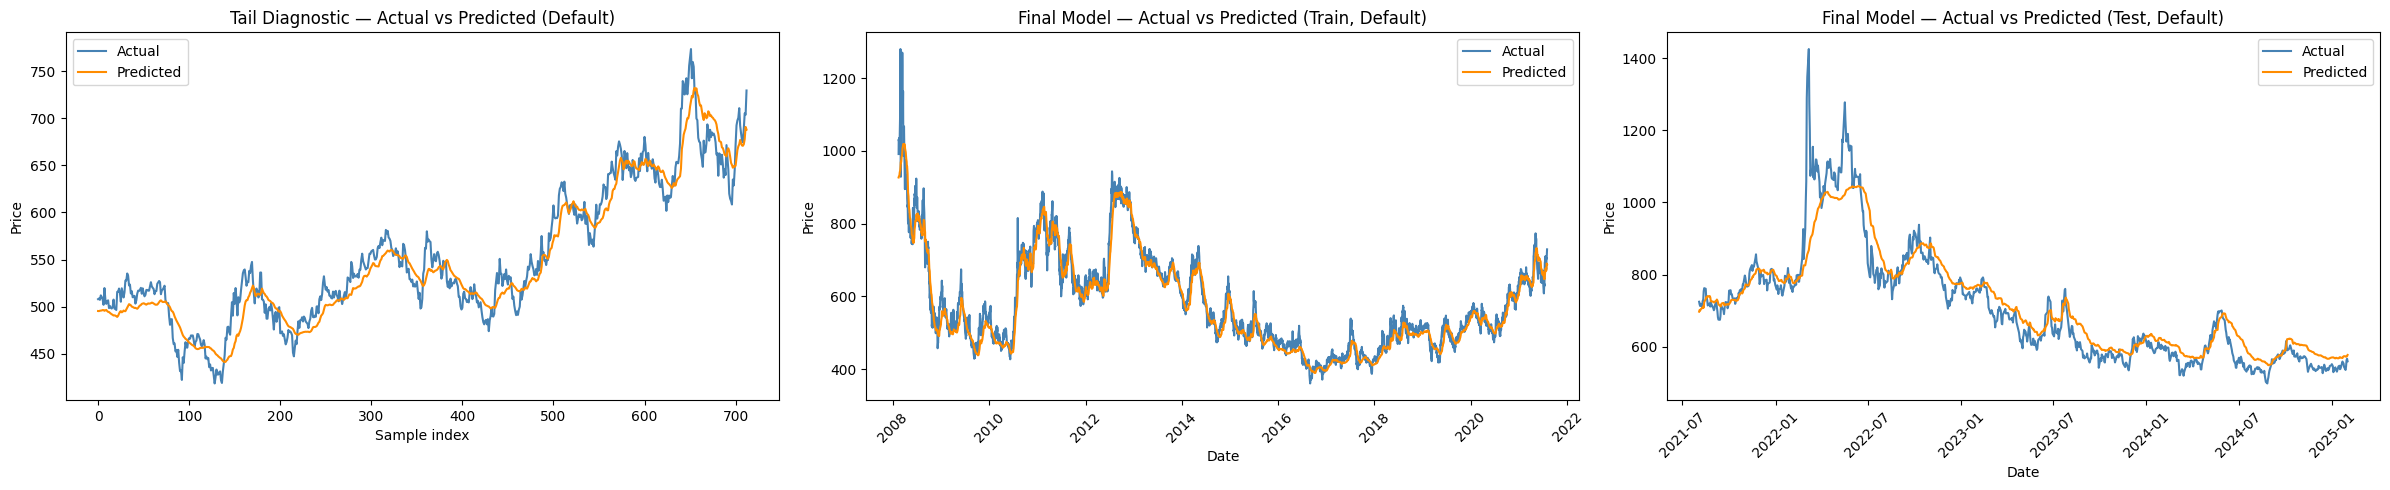

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(24, 5))

# Tail diagnostic predictions
axes[0].plot(default_model._cv_val_actual, label='Actual', color='steelblue')
axes[0].plot(default_model._cv_val_pred, label='Predicted', color='darkorange')
axes[0].set_title('Tail Diagnostic — Actual vs Predicted (Default)')
axes[0].set_xlabel('Sample index')
axes[0].set_ylabel('Price')
axes[0].legend()

# Train predictions
train_dates = df_all.index[lookback:lookback + len(y_train)]
default_train_preds = default_model.predict(X_train)

axes[1].plot(train_dates, y_train, label='Actual', color='steelblue')
axes[1].plot(train_dates, default_train_preds, label='Predicted', color='darkorange')
axes[1].set_title('Final Model — Actual vs Predicted (Train, Default)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Price')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

# Test predictions
test_dates = df_all.index[-len(X_test):]
default_test_preds = default_model.predict(X_test)

axes[2].plot(test_dates, y_test, label='Actual', color='steelblue')
axes[2].plot(test_dates, default_test_preds, label='Predicted', color='darkorange')
axes[2].set_title('Final Model — Actual vs Predicted (Test, Default)')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Price')
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend()

plt.tight_layout()
plt.show()


## Optuna Hyperparameter Search (BiRNN + Skip (No Attention))

Hyperparameters tuned: hidden_size, num_layers, weight_decay, dropout, early_stop_patience, epochs, batch_size, and learning_rate.

In [18]:
def objective(trial):
    params = dict(
        hidden_size=trial.suggest_categorical('hidden_size', [32, 64, 128]),
        num_layers=trial.suggest_categorical('num_layers', [1, 2, 3]),
        weight_decay=trial.suggest_float('weight_decay', 5e-4, 2e-2, log=True),
        dropout=trial.suggest_float('dropout', 0.1, 0.3),
        early_stop_patience=trial.suggest_int('early_stop_patience', 10, 15),
        epochs=trial.suggest_int('epochs', 50, 200),
        batch_size=trial.suggest_categorical('batch_size', [32, 64]),
        learning_rate=trial.suggest_float('learning_rate', 1e-4, 1e-3, log=True),
    )
    result = cv_birnn_skip_only(X_train, y_train, **params)
    trial.set_user_attr('cv_metrics', result)
    return result['val_loss']


N_TRIALS = 25
study = optuna.create_study(direction='minimize')
progress_bar = tqdm(total=N_TRIALS, desc='Optuna trials')
study.optimize(objective, n_trials=N_TRIALS, callbacks=[lambda study, trial: progress_bar.update(1)])
progress_bar.close()

print('\nBest CV score (val_loss):', study.best_value)
print('Best hyperparameters:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

optuna_cv_metrics = study.best_trial.user_attrs['cv_metrics']
print('\n=== Optuna CV Metrics (avg across 5 folds) ===')
for k, v in optuna_cv_metrics.items():
    print(f'  {k.upper():<10}: {v:.6f}')

[I 2026-02-22 19:01:53,818] A new study created in memory with name: no-name-ce00aab9-4174-40de-b4ae-87f9041371db


Optuna trials:   0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

[I 2026-02-22 19:09:25,626] Trial 0 finished with value: 2.393464504182339 and parameters: {'hidden_size': 128, 'num_layers': 3, 'weight_decay': 0.0037467700394602206, 'dropout': 0.11621279736929827, 'early_stop_patience': 15, 'epochs': 101, 'batch_size': 32, 'learning_rate': 0.0005261483061165099}. Best is trial 0 with value: 2.393464504182339.


  0%|          | 0/5 [00:00<?, ?it/s]

...

  0%|          | 0/5 [00:00<?, ?it/s]

[I 2026-02-22 20:16:34,679] Trial 23 finished with value: 0.349058735370636 and parameters: {'hidden_size': 64, 'num_layers': 1, 'weight_decay': 0.0005301122639986766, 'dropout': 0.2583298368303152, 'early_stop_patience': 15, 'epochs': 163, 'batch_size': 64, 'learning_rate': 0.0002680049843039686}. Best is trial 10 with value: 0.22781267166137695.


  0%|          | 0/5 [00:00<?, ?it/s]

[I 2026-02-22 20:18:28,346] Trial 24 finished with value: 0.3429105311632156 and parameters: {'hidden_size': 64, 'num_layers': 1, 'weight_decay': 0.0005246370198676727, 'dropout': 0.2514856048297429, 'early_stop_patience': 15, 'epochs': 162, 'batch_size': 64, 'learning_rate': 0.00025152213254197204}. Best is trial 10 with value: 0.22781267166137695.



Best CV score (val_loss): 0.22781267166137695
Best hyperparameters:
  hidden_size: 32
  num_layers: 1
  weight_decay: 0.0005613125212895943
  dropout: 0.2992773920628471
  early_stop_patience: 13
  epochs: 150
  batch_size: 64
  learning_rate: 0.0009571537403221412

=== Optuna CV Metrics (avg across 5 folds) ===
  VAL_LOSS  : 0.227813
  RMSE      : 56.177210
  MAE       : 44.144600
  R2        : 0.399223


## Train, Evaluate & Plot (BiRNN + Skip (No Attention) with Optuna best hyperparameters)

In [19]:
best_params = study.best_params

optuna_model = BiRNNSkipOnlyModel(
    task_type='regression',
    hidden_size=best_params['hidden_size'],
    num_layers=best_params['num_layers'],
    weight_decay=best_params['weight_decay'],
    dropout=best_params['dropout'],
    early_stop_patience=best_params['early_stop_patience'],
    epochs=best_params['epochs'],
    batch_size=best_params['batch_size'],
    learning_rate=best_params['learning_rate'],
)

optuna_model.fit(X_train, y_train)

optuna_test_metrics = optuna_model.evaluate(X_test, y_test)
print('\n=== Optuna — Test set performance ===')
for k, v in optuna_test_metrics.items():
    print(f'  {k.upper():<10}: {v:.6f}')

=== Train set performance (full X_train) ===
  RMSE: 36.926702
  MAE : 25.956802
  R_SQUARED  : 0.925296
=== Tail diagnostic performance (last 20% of X_train) ===
  RMSE: 26.115915
  MAE : 20.023757
  R_SQUARED  : 0.868534

=== Optuna — Test set performance ===
  RMSE      : 108.879897
  MAE       : 71.856285
  R2        : 0.549347


### Optuna — Tail Diagnostic, Train & Test plots

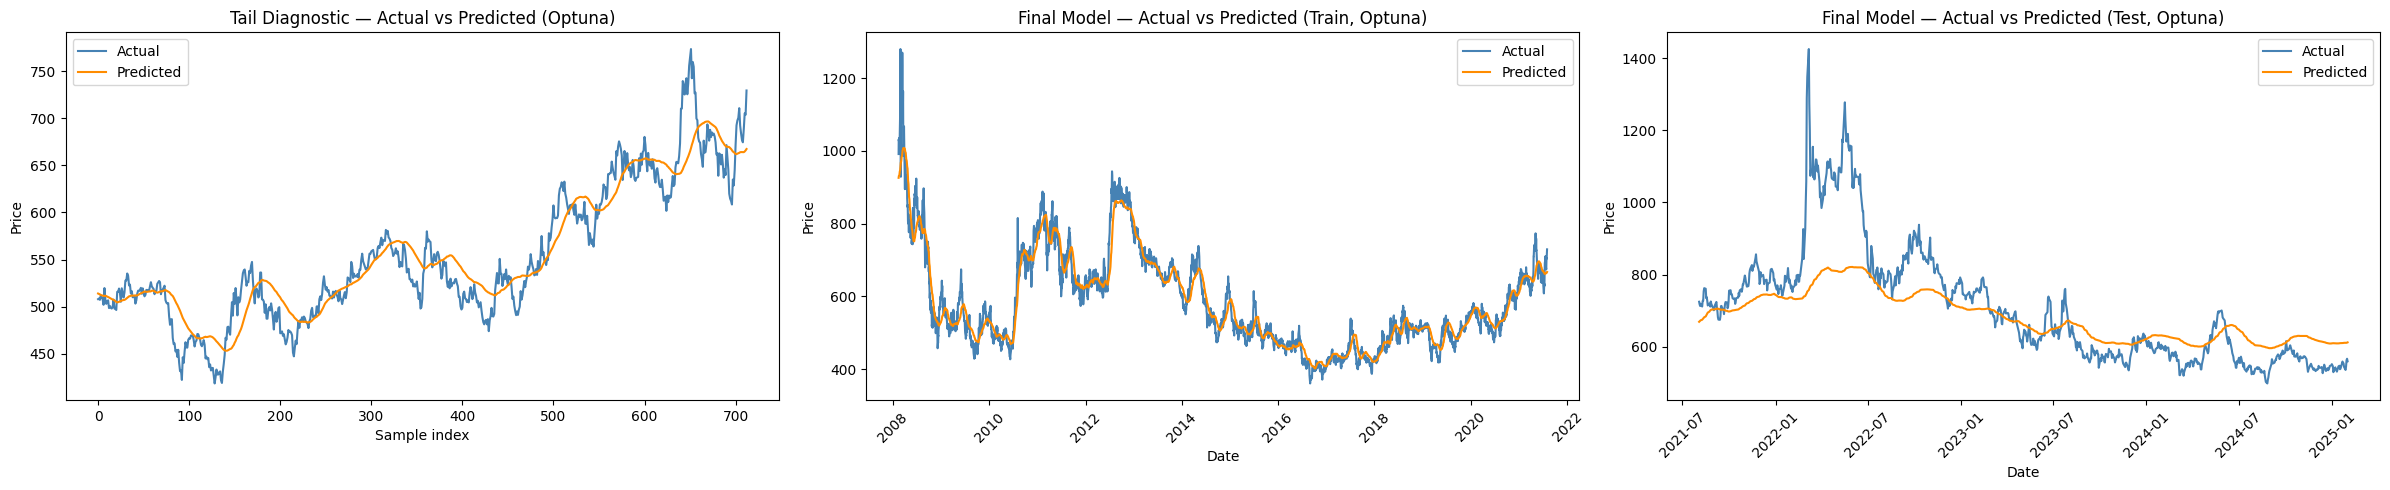

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(24, 5))

# Tail diagnostic predictions
axes[0].plot(optuna_model._cv_val_actual, label='Actual', color='steelblue')
axes[0].plot(optuna_model._cv_val_pred, label='Predicted', color='darkorange')
axes[0].set_title('Tail Diagnostic — Actual vs Predicted (Optuna)')
axes[0].set_xlabel('Sample index')
axes[0].set_ylabel('Price')
axes[0].legend()

# Train predictions
train_dates = df_all.index[lookback:lookback + len(y_train)]
optuna_train_preds = optuna_model.predict(X_train)

axes[1].plot(train_dates, y_train, label='Actual', color='steelblue')
axes[1].plot(train_dates, optuna_train_preds, label='Predicted', color='darkorange')
axes[1].set_title('Final Model — Actual vs Predicted (Train, Optuna)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Price')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

# Test predictions
test_dates = df_all.index[-len(X_test):]
optuna_test_preds = optuna_model.predict(X_test)

axes[2].plot(test_dates, y_test, label='Actual', color='steelblue')
axes[2].plot(test_dates, optuna_test_preds, label='Predicted', color='darkorange')
axes[2].set_title('Final Model — Actual vs Predicted (Test, Optuna)')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Price')
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend()

plt.tight_layout()
plt.show()


## Naive Baseline

Each day's price prediction equals the previous day's price.

In [21]:
last_train_price = y_train[-1]
naive_preds = np.empty(len(y_test))
naive_preds[0] = last_train_price
naive_preds[1:] = y_test[:-1]

naive_rmse = np.sqrt(mean_squared_error(y_test, naive_preds))
naive_mae = mean_absolute_error(y_test, naive_preds)
naive_r2 = r2_score(y_test, naive_preds)

print('=== Naive One-Day-Ahead Forecast ===')
print(f'RMSE: {naive_rmse:.6f}')
print(f'R_SQUARED  : {naive_r2:.6f}')
print(f'MAE : {naive_mae:.6f}')

=== Naive One-Day-Ahead Forecast ===
RMSE: 20.370589
R_SQUARED  : 0.984226
MAE : 12.850842


## Model Comparison

In [22]:
comparison = pd.DataFrame([
    {
        'Model': 'Naive',
        'RMSE': naive_rmse,
        'MAE': naive_mae,
        'R_SQUARED': naive_r2,
    },
    {
        'Model': 'BiRNN + Skip Only (Default CV)',
        'RMSE': default_cv_metrics['rmse'],
        'MAE': default_cv_metrics['mae'],
        'R_SQUARED': default_cv_metrics['r2'],
    },
    {
        'Model': 'BiRNN + Skip Only (Default Final)',
        'RMSE': default_test_metrics['rmse'],
        'MAE': default_test_metrics['mae'],
        'R_SQUARED': default_test_metrics['r2'],
    },
    {
        'Model': 'BiRNN + Skip Only (Optuna CV)',
        'RMSE': optuna_cv_metrics['rmse'],
        'MAE': optuna_cv_metrics['mae'],
        'R_SQUARED': optuna_cv_metrics['r2'],
    },
    {
        'Model': 'BiRNN + Skip Only (Optuna Final)',
        'RMSE': optuna_test_metrics['rmse'],
        'MAE': optuna_test_metrics['mae'],
        'R_SQUARED': optuna_test_metrics['r2'],
    },
])

comparison = comparison.set_index('Model')

comparison.style \
    .highlight_min(subset=['RMSE', 'MAE'], color='#d4edda') \
    .highlight_max(subset=['R_SQUARED'], color='#d4edda') \
    .format('{:.6f}')

,RMSE,MAE,R_SQUARED
Model,,,
Naive,20.370589,12.850842,0.984226
BiRNN + Skip Only (Default CV),57.184699,47.349063,0.336503
BiRNN + Skip Only (Default Final),59.056541,37.991724,0.867418
BiRNN + Skip Only (Optuna CV),56.177210,44.144600,0.399223
BiRNN + Skip Only (Optuna Final),108.879897,71.856285,0.549347


## Save & Load

In [23]:
optuna_model.save('birnn_skip_only_wheat')

loaded = BiRNNSkipOnlyModel()
loaded.load('birnn_skip_only_wheat')

loaded_metrics = loaded.evaluate(X_test, y_test)
print('\nLoaded model test metrics:')
for name, value in loaded_metrics.items():
    print(f'  {name.upper()}: {value:.6f}')

print(f"\nPredictions match: {np.allclose(optuna_model.predict(X_test), loaded.predict(X_test))}")

Model saved to birnn_skip_only_wheat.*
Model loaded from birnn_skip_only_wheat.*

Loaded model test metrics:
  RMSE: 108.879897
  MAE: 71.856285
  R2: 0.549347

Predictions match: True
